<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/GARCH_QTFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 13.8 MB/s eta 0:00:00


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
from google.colab import userdata
import sys
from google.colab import drive
from arch import arch_model
from arch.univariate import ConstantMean, GARCH, StudentsT, FIGARCH
data_futures = pd.read_csv(userdata.get('data_path'))

In [26]:
# 1. Parse date and filter relevant contracts
data = data_futures.copy()
data["date"] = pd.to_datetime(data["date"])
data = data[data["symbol"].isin(["ES", "CL", 'C', 'GC', 'NG'])].sort_values(["symbol", "date"])

# 2. Compute daily percentage log returns: r_t = 100 * ln(Close_t / Close_{t-1})
# Multiplying by 100 is standard practice to prevent tiny decimals from destabilizing MLE optimizers
data["ret"] = data.groupby("symbol")["close_price"].transform(
    lambda x: np.log(x / x.shift(1)) * 100
)
# 3. Scale Realized Variance if needed (match the scale of returns^2)
# If returns are in %, variance should be scaled by 100^2 = 10,000
data["log_rv_scaled"] = np.log(data["rk"] * 10000)
data["rk_scaled"] = data["rk"] * 10000

# 4. Pivot into a clean wide DataFrame aligned on Date
df = data.pivot(
    index="date",
    columns="symbol",
    values=["close_price", "ret", "log_rv_scaled", "rk", "rk_scaled"],
)

# Flatten MultiIndex columns (e.g., ret_ES, rv_CL)
df.columns = [f"{col}_{sym}" for col, sym in df.columns]

# Drop trading calendar mismatches / initial NaNs
df = df.dropna()

In [30]:
df.columns

Index(['close_price_C', 'close_price_CL', 'close_price_ES', 'close_price_GC',
       'close_price_NG', 'ret_C', 'ret_CL', 'ret_ES', 'ret_GC', 'ret_NG',
       'log_rv_scaled_C', 'log_rv_scaled_CL', 'log_rv_scaled_ES',
       'log_rv_scaled_GC', 'log_rv_scaled_NG', 'rk_C', 'rk_CL', 'rk_ES',
       'rk_GC', 'rk_NG', 'rk_scaled_C', 'rk_scaled_CL', 'rk_scaled_ES',
       'rk_scaled_GC', 'rk_scaled_NG'],
      dtype='object')

In [29]:
df.to_csv("volatility_model_QTFE_data.csv", index=True)

In [6]:
# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "ret" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
ret_C,-67.2516,0.0000e+00,0.0787,0.1,Stationary
ret_CL,-10.6288,5.2784e-19,0.0373,0.1,Stationary
ret_ES,-14.9578,1.2527e-27,0.0222,0.1,Stationary
ret_GC,-65.8138,0.0000e+00,0.3073,0.1,Stationary
ret_NG,-68.8376,0.0000e+00,0.0282,0.1,Stationary


In [8]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "scaled" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
log_rv_scaled_C,-6.5968,6.8922e-09,1.2459,0.0100,Contradictory / Structural Break
log_rv_scaled_CL,-5.0090,2.1304e-05,1.2909,0.0100,Contradictory / Structural Break
log_rv_scaled_ES,-6.1398,8.0244e-08,0.3825,0.0847,Stationary
log_rv_scaled_GC,-5.8203,4.1981e-07,0.8519,0.0100,Contradictory / Structural Break
log_rv_scaled_NG,-4.5309,1.7285e-04,3.0578,0.0100,Contradictory / Structural Break


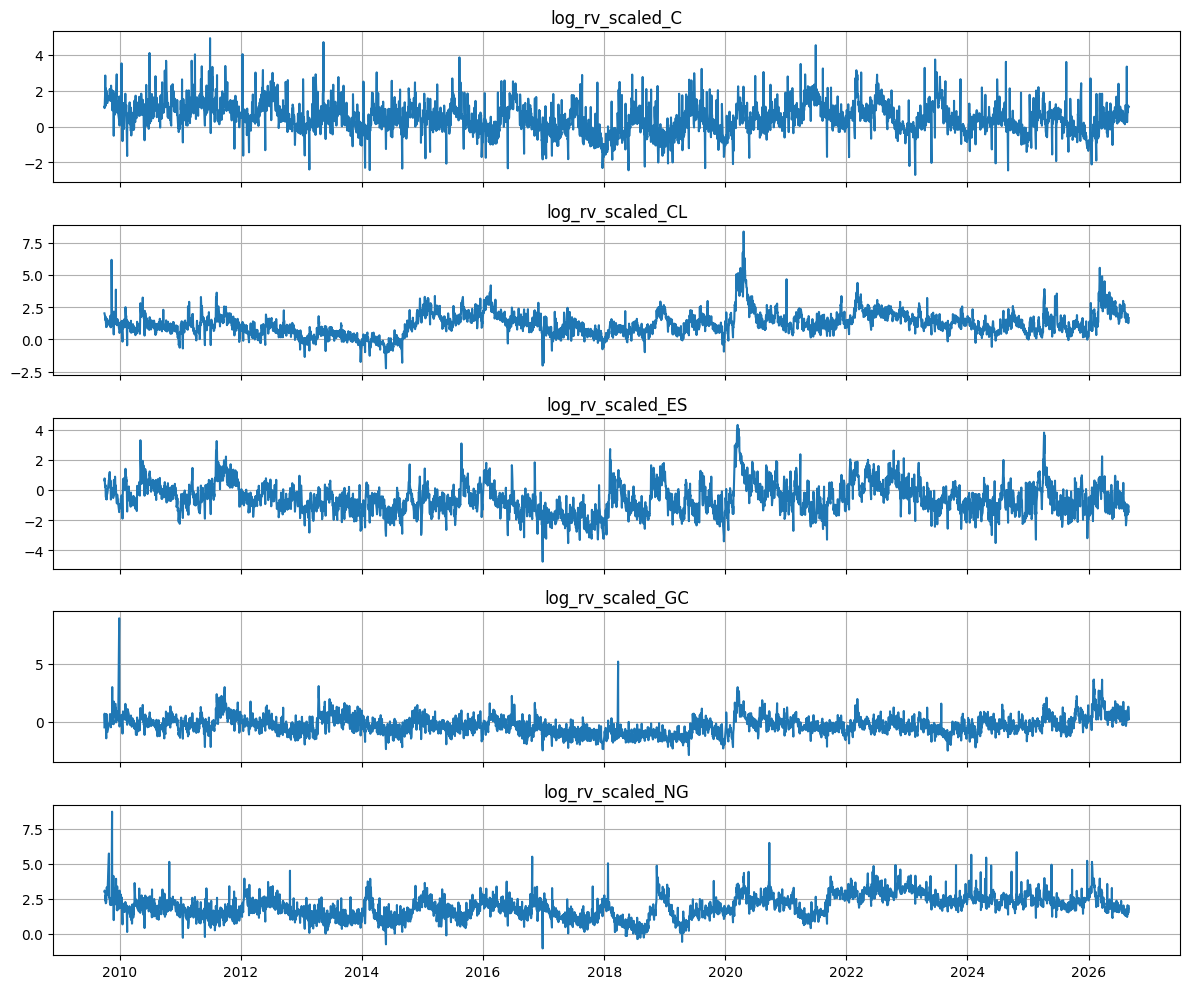

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
columns_to_plot = [col for col in df.columns if "scaled" in col]

for i, col in enumerate(columns_to_plot):
    axes[i].plot(df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['close_price_C', 'close_price_CL', 'close_price_ES', 'close_price_GC',
       'close_price_NG', 'ret_C', 'ret_CL', 'ret_ES', 'ret_GC', 'ret_NG',
       'log_rv_scaled_C', 'log_rv_scaled_CL', 'log_rv_scaled_ES',
       'log_rv_scaled_GC', 'log_rv_scaled_NG', 'rk_C', 'rk_CL', 'rk_ES',
       'rk_GC', 'rk_NG'],
      dtype='object')

In [11]:
# 1. Target series (Equity log returns in percentage terms)
y = df["ret_ES"].dropna()

# 2. Construct strictly lagged exogenous volatility regressors
# Using log realized variance (or sqrt realized variance)
x_oil = df["log_rv_scaled_CL"].shift(1)

# If you have your bond/rate volatility column (e.g. log_rv_scaled_ZN):
x_corn = df['log_rv_scaled_C'].shift(1)
x_gold = df['log_rv_scaled_GC'].shift(1)
x_gas = df['log_rv_scaled_NG'].shift(1)


# Align data and drop the single NaN from shifting
model_df = (
    pd.DataFrame(
        {
            "ret_ES": y,
            "x_oil": x_oil,
            'x_corn': x_corn,
            'x_gold': x_gold,
            'x_gas': x_gas,
        }
    )
    .dropna()
    .copy()
)

y_clean = model_df["ret_ES"]
x_oil_clean = model_df[["x_oil"]]

In [12]:
# Baseline GARCH(1,1) with Constant Mean and Student-t innovations
base_garch = arch_model(
    y_clean, mean="Constant", vol="GARCH", p=1, q=1, dist="StudentsT"
)
res_base = base_garch.fit(update_freq=0, disp="off")
print(res_base.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       ret_ES   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5403.74
Distribution:      Standardized Student's t   AIC:                           10817.5
Method:                  Maximum Likelihood   BIC:                           10849.3
                                              No. Observations:                 4310
Date:                      Sat, Sep 26 2026   Df Residuals:                     4309
Time:                              07:12:12   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [13]:
# GARCH-X with Oil Volatility
garch_x_oil = arch_model(
    y_clean,
    x=x_oil_clean,  # Regressor added to variance equation
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="StudentsT",
)
res_oil = garch_x_oil.fit(update_freq=0, disp="off")
print(res_oil.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       ret_ES   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5403.74
Distribution:      Standardized Student's t   AIC:                           10817.5
Method:                  Maximum Likelihood   BIC:                           10849.3
                                              No. Observations:                 4310
Date:                      Sat, Sep 26 2026   Df Residuals:                     4309
Time:                              07:12:12   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [15]:
model_df.columns

Index(['ret_ES', 'x_oil', 'x_corn', 'x_gold', 'x_gas'], dtype='object')

In [20]:
x_lagged = model_df[['x_oil', 'x_corn']].dropna()
y_aligned = y_clean.loc[x_lagged.index]
model = ConstantMean(y_aligned)

# Define the Volatility equation with Exogenous Regressors
# Setting truncation=None and d=0 effectively yields a GARCH(1,1)-X specification
# where extra_regressors enter the variance recursion:
# sigma_t^2 = omega + alpha * e_{t-1}^2 + beta * sigma_{t-1}^2 + gamma' X_{t-1}
model.volatility = FIGARCH(p=1, q=1, truncation=1000)

# Pass the exogenous regressors into the volatility process
# (Note: In arch, extra_regressors in FIGARCH/GARCH handle the X terms)
model.volatility.extra_regressors = x_lagged.values

# ---------------------------------------------------------
# 3. Set the Error Distribution (Student's t)
# ---------------------------------------------------------
model.distribution = StudentsT()

# ---------------------------------------------------------
# 4. Fit the GARCH-X Model via MLE
# ---------------------------------------------------------
res_garch_x = model.fit(update_freq=0, disp='off')
print(res_garch_x.summary())

                       Constant Mean - FIGARCH Model Results                        
Dep. Variable:                       ret_ES   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                          FIGARCH   Log-Likelihood:               -5396.17
Distribution:      Standardized Student's t   AIC:                           10804.3
Method:                  Maximum Likelihood   BIC:                           10842.5
                                              No. Observations:                 4310
Date:                      Sat, Sep 26 2026   Df Residuals:                     4309
Time:                              07:20:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        